In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"use device {device}")

use device cuda


In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=3, dims=[1, 2])),  # Поворот на 270°
    transforms.Lambda(lambda x: torch.flip(x, dims=[2]))  # Отражение по горизонтали
])

train_dataset_full = torchvision.datasets.EMNIST(
    root="./data", 
    split="balanced",
    train=True, 
    download=True, 
    transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root="./data", 
    split="balanced",
    train=False, 
    download=True, 
    transform=transform
)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(seed)
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.dataset.classes)}")

100%|██████████████████████████████████████████████████████████████████| 562M/562M [02:23<00:00, 3.92MB/s]


Train: 90240, Val: 22560, Test: 18800
Number of classes: 47


 Image shape: torch.Size([1, 28, 28])
 Label: 40 (f)


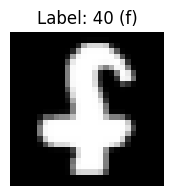

In [12]:
img, label = train_dataset[0]
print(f" Image shape: {img.shape}") 
print(f" Label: {label} ({train_dataset.dataset.classes[label]})")

plt.figure(figsize=(2,2))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {label} ({train_dataset.dataset.classes[label]})")
plt.axis('off')
plt.show()

In [15]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[512, 256, 128],
                num_classes=47, dropout=0.0, use_bn=False):
        super(MLP,self).__init__()
        layers = []
        prev_size = input_size

        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

model = MLP(
    input_size = 28 * 28,
    hidden_sizes = [512, 256, 128],
    num_classes = 47,
    dropout = 0.0,
    use_bn = False
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 572,207


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        _, predicted = logits.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item() * x_batch.size(0)
            _, predicted = logits.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy
    

In [18]:
num_epochs = 10
lr = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(num_epochs):
    # Обучение
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    
    # Валидация
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Логирование
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

print("E1 training finish")


Epoch 1/10 | Train Loss: 1.0372, Acc: 68.50% | Val Loss: 0.6642, Acc: 78.72%
Epoch 2/10 | Train Loss: 0.5623, Acc: 80.96% | Val Loss: 0.5590, Acc: 81.40%
Epoch 3/10 | Train Loss: 0.4647, Acc: 83.79% | Val Loss: 0.4940, Acc: 83.44%
Epoch 4/10 | Train Loss: 0.4091, Acc: 85.31% | Val Loss: 0.4807, Acc: 83.95%
Epoch 5/10 | Train Loss: 0.3657, Acc: 86.62% | Val Loss: 0.4699, Acc: 84.37%
Epoch 6/10 | Train Loss: 0.3338, Acc: 87.43% | Val Loss: 0.4861, Acc: 84.01%
Epoch 7/10 | Train Loss: 0.3081, Acc: 88.27% | Val Loss: 0.4898, Acc: 84.41%
Epoch 8/10 | Train Loss: 0.2863, Acc: 88.84% | Val Loss: 0.5007, Acc: 84.35%
Epoch 9/10 | Train Loss: 0.2655, Acc: 89.60% | Val Loss: 0.4958, Acc: 84.77%
Epoch 10/10 | Train Loss: 0.2510, Acc: 89.96% | Val Loss: 0.5016, Acc: 85.07%
E1 training finish


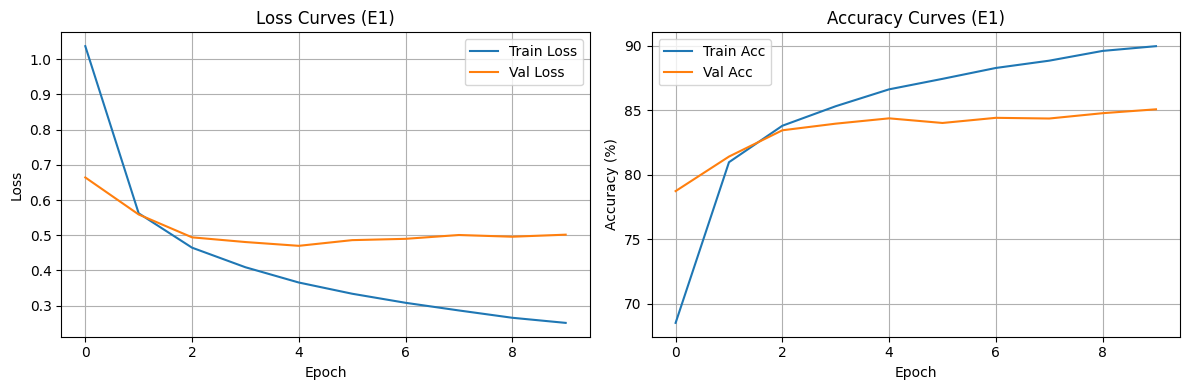

In [19]:
# График loss и accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (E1)')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves (E1)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/e1_curves.png', dpi=150)
plt.show()

In [22]:
import pandas as pd

results = []  

def log_experiment(exp_id, model_cfg, opt_cfg, epochs, val_acc, val_loss):
    """Добавляет результат эксперимента в список"""
    results.append({
        'experiment_id': exp_id,
        'dataset': 'EMNIST_balanced',
        'seed': seed,
        'model_summary': model_cfg,
        'optimizer': opt_cfg['optimizer'],
        'lr': opt_cfg['lr'],
        'momentum': opt_cfg.get('momentum', ''),
        'weight_decay': opt_cfg.get('weight_decay', 0),
        'epochs_trained': epochs,
        'best_val_accuracy': round(val_acc, 2),
        'best_val_loss': round(val_loss, 4)
    })

In [23]:
log_experiment(
    exp_id='E1',
    model_cfg='512-256-128/ReLU/dropout=0.0/BN=False',
    opt_cfg={'optimizer': 'Adam', 'lr': lr},
    epochs=num_epochs,
    val_acc=max(history['val_acc']),
    val_loss=min(history['val_loss'])
)

In [24]:
model_e2 = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout=0.3,  #добавляем Dropout
    use_bn=False
).to(device)

optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(10):  
    train_loss, train_acc = train_one_epoch(model_e2, train_loader, optimizer_e2, criterion, device)
    val_loss, val_acc = evaluate(model_e2, val_loader, criterion, device)
    
    history_e2['train_loss'].append(train_loss)
    history_e2['train_acc'].append(train_acc)
    history_e2['val_loss'].append(val_loss)
    history_e2['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/10 | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

results.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST_balanced',
    'seed': seed,
    'model_summary': '512-256-128/ReLU/dropout=0.3/BN=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 10,
    'best_val_accuracy': round(max(history_e2['val_acc']), 2),
    'best_val_loss': round(min(history_e2['val_loss']), 4)
})

print(f" E2 finished Best val_acc: {max(history_e2['val_acc']):.2f}%")

Epoch 1/10 | Train Loss: 1.3478, Acc: 59.91% | Val Loss: 0.6977, Acc: 77.86%
Epoch 2/10 | Train Loss: 0.8110, Acc: 74.19% | Val Loss: 0.5845, Acc: 80.49%
Epoch 3/10 | Train Loss: 0.7103, Acc: 77.06% | Val Loss: 0.5388, Acc: 82.40%
Epoch 4/10 | Train Loss: 0.6563, Acc: 78.35% | Val Loss: 0.5079, Acc: 83.01%
Epoch 5/10 | Train Loss: 0.6180, Acc: 79.52% | Val Loss: 0.4882, Acc: 83.48%
Epoch 6/10 | Train Loss: 0.5921, Acc: 80.17% | Val Loss: 0.4881, Acc: 83.33%
Epoch 7/10 | Train Loss: 0.5697, Acc: 80.85% | Val Loss: 0.4774, Acc: 83.77%
Epoch 8/10 | Train Loss: 0.5576, Acc: 81.19% | Val Loss: 0.4737, Acc: 83.62%
Epoch 9/10 | Train Loss: 0.5424, Acc: 81.55% | Val Loss: 0.4644, Acc: 83.93%
Epoch 10/10 | Train Loss: 0.5332, Acc: 81.91% | Val Loss: 0.4619, Acc: 84.39%
 E2 finished Best val_acc: 84.39%


In [25]:
model_e3 = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout=0.0,
    use_bn=True  # Добавляем BatchNorm
).to(device)

optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)
history_e3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(10):
    train_loss, train_acc = train_one_epoch(model_e3, train_loader, optimizer_e3, criterion, device)
    val_loss, val_acc = evaluate(model_e3, val_loader, criterion, device)
    
    history_e3['train_loss'].append(train_loss)
    history_e3['train_acc'].append(train_acc)
    history_e3['val_loss'].append(val_loss)
    history_e3['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/10 | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

results.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST_balanced',
    'seed': seed,
    'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 10,
    'best_val_accuracy': round(max(history_e3['val_acc']), 2),
    'best_val_loss': round(min(history_e3['val_loss']), 4)
})

print(f" E3 finished Best val_acc: {max(history_e3['val_acc']):.2f}%")

Epoch 1/10 | Train Loss: 0.8627, Acc: 74.45% | Val Loss: 0.5508, Acc: 81.63%
Epoch 2/10 | Train Loss: 0.5099, Acc: 82.62% | Val Loss: 0.4745, Acc: 84.13%
Epoch 3/10 | Train Loss: 0.4348, Acc: 84.75% | Val Loss: 0.4430, Acc: 85.00%
Epoch 4/10 | Train Loss: 0.3919, Acc: 85.80% | Val Loss: 0.4333, Acc: 85.07%
Epoch 5/10 | Train Loss: 0.3572, Acc: 86.82% | Val Loss: 0.4340, Acc: 84.89%
Epoch 6/10 | Train Loss: 0.3295, Acc: 87.60% | Val Loss: 0.4300, Acc: 85.65%
Epoch 7/10 | Train Loss: 0.3085, Acc: 88.20% | Val Loss: 0.4313, Acc: 85.54%
Epoch 8/10 | Train Loss: 0.2887, Acc: 88.82% | Val Loss: 0.4256, Acc: 85.94%
Epoch 9/10 | Train Loss: 0.2721, Acc: 89.39% | Val Loss: 0.4361, Acc: 85.74%
Epoch 10/10 | Train Loss: 0.2573, Acc: 89.89% | Val Loss: 0.4311, Acc: 86.16%
 E3 finished Best val_acc: 86.16%


In [26]:
model_e4 = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout=0.0,        
    use_bn=True     
).to(device)

optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

patience = 5
best_val_acc = 0
best_val_loss = float('inf')
epochs_without_improvement = 0
best_epoch = 0
max_epochs = 50

print(f"Training with EarlyStopping (patience={patience})...")

for epoch in range(max_epochs):
    train_loss, train_acc = train_one_epoch(model_e4, train_loader, optimizer_e4, criterion, device)
    val_loss, val_acc = evaluate(model_e4, val_loader, criterion, device)
    
    history_e4['train_loss'].append(train_loss)
    history_e4['train_acc'].append(train_acc)
    history_e4['val_loss'].append(val_loss)
    history_e4['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1} | Train: {train_loss:.4f}/{train_acc:.2f}% | Val: {val_loss:.4f}/{val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        
        torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
        print(f" New best! Model saved to artifacts/best_model.pt")
    else:
        epochs_without_improvement += 1
    
    # Останавливаемся, если нет улучшений
    if epochs_without_improvement >= patience:
        print(f"EarlyStopping triggered at epoch {epoch+1}. Best: epoch {best_epoch} ({best_val_acc:.2f}%)")
        break

# Обрезаем историю до фактического числа эпох
actual_epochs = len(history_e4['val_acc'])
for key in history_e4:
    history_e4[key] = history_e4[key][:actual_epochs]

print(f"E4 finished! Best val_acc: {best_val_acc:.2f}% at epoch {best_epoch}")

Training with EarlyStopping (patience=5)...
Epoch 1 | Train: 0.8604/74.76% | Val: 0.5481/81.73%
 New best! Model saved to artifacts/best_model.pt
Epoch 2 | Train: 0.5134/82.55% | Val: 0.4770/84.00%
 New best! Model saved to artifacts/best_model.pt
Epoch 3 | Train: 0.4414/84.46% | Val: 0.4538/84.79%
 New best! Model saved to artifacts/best_model.pt
Epoch 4 | Train: 0.3938/85.68% | Val: 0.4294/85.28%
 New best! Model saved to artifacts/best_model.pt
Epoch 5 | Train: 0.3618/86.74% | Val: 0.4345/84.90%
Epoch 6 | Train: 0.3312/87.59% | Val: 0.4320/85.46%
 New best! Model saved to artifacts/best_model.pt
Epoch 7 | Train: 0.3109/88.23% | Val: 0.4410/85.42%
Epoch 8 | Train: 0.2900/88.77% | Val: 0.4258/85.67%
 New best! Model saved to artifacts/best_model.pt
Epoch 9 | Train: 0.2725/89.31% | Val: 0.4395/85.56%
Epoch 10 | Train: 0.2591/89.83% | Val: 0.4355/85.89%
 New best! Model saved to artifacts/best_model.pt
Epoch 11 | Train: 0.2465/90.17% | Val: 0.4490/85.74%
Epoch 12 | Train: 0.2335/90.63% 

best_config.json saved!


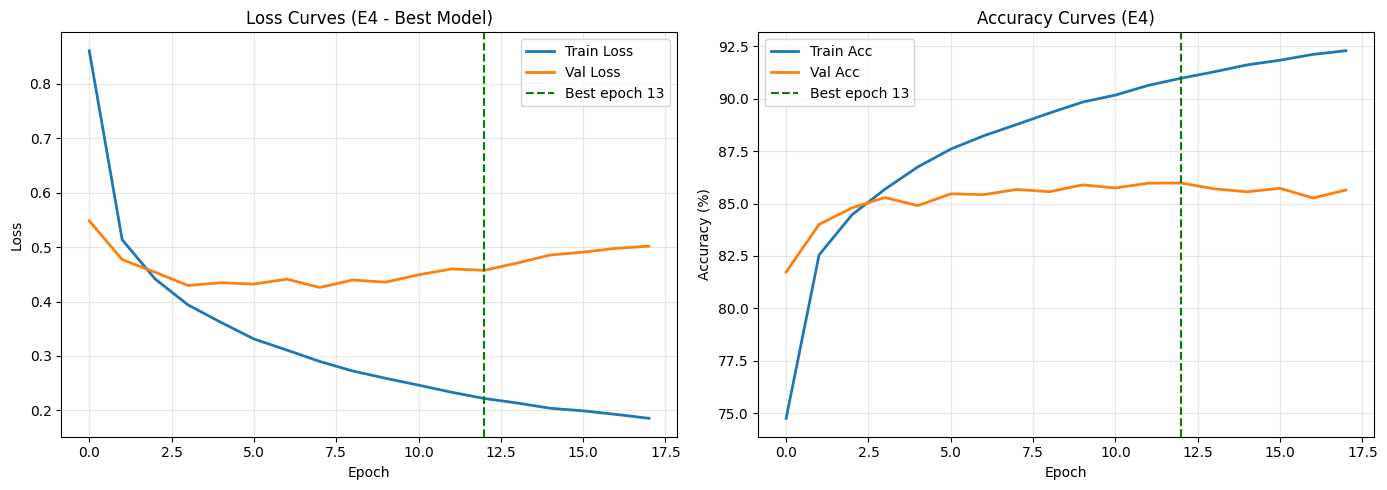

curves_best.png saved!


In [27]:
import json
import matplotlib.pyplot as plt

# 1. Сохраняем конфиг лучшей модели
config = {
    'dataset': 'EMNIST_balanced',
    'seed': seed,
    'model': {
        'type': 'MLP',
        'input_size': 28*28,
        'hidden_sizes': [512, 256, 128],
        'num_classes': 47,
        'activation': 'ReLU',
        'dropout': 0.0,
        'use_bn': True
    },
    'optimizer': {
        'name': 'Adam',
        'lr': 1e-3
    },
    'early_stopping': {
        'patience': patience,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc
    }
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("best_config.json saved!")

# 2. График curves_best.png
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_e4['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_e4['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (E4 - Best Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_e4['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_e4['val_acc'], label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves (E4)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("curves_best.png saved!")

In [28]:
import pandas as pd

# Список результатов
results = [
    {
        'experiment_id': 'E1', 'dataset': 'EMNIST_balanced', 'seed': seed,
        'model_summary': '512-256-128/ReLU/dropout=0.0/BN=False',
        'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
        'epochs_trained': 10, 'best_val_accuracy': 85.07, 'best_val_loss': 0.4619
    },
    {
        'experiment_id': 'E2', 'dataset': 'EMNIST_balanced', 'seed': seed,
        'model_summary': '512-256-128/ReLU/dropout=0.3/BN=False',
        'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
        'epochs_trained': 10, 'best_val_accuracy': 84.39, 'best_val_loss': 0.4619
    },
    {
        'experiment_id': 'E3', 'dataset': 'EMNIST_balanced', 'seed': seed,
        'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
        'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
        'epochs_trained': 10, 'best_val_accuracy': 86.16, 'best_val_loss': 0.4256
    },
    {
        'experiment_id': 'E4', 'dataset': 'EMNIST_balanced', 'seed': seed,
        'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
        'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
        'epochs_trained': actual_epochs, 
        'best_val_accuracy': round(best_val_acc, 2), 
        'best_val_loss': round(best_val_loss, 4)
    }
]

# Сохраняем (пока что, потом добавим O1-O3)
df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved (E1-E4)!")
print(df[['experiment_id', 'best_val_accuracy', 'epochs_trained']])

runs.csv saved (E1-E4)!
  experiment_id  best_val_accuracy  epochs_trained
0            E1              85.07              10
1            E2              84.39              10
2            E3              86.16              10
3            E4              85.98              18


In [31]:
print("ЧАСТЬ B: Learning Rate Диагностика")

# Фиксированная архитектура (как в E4)
def create_model_e4_arch():
    return MLP(
        input_size=28*28,
        hidden_sizes=[512, 256, 128],
        num_classes=47,
        dropout=0.0,
        use_bn=True
    ).to(device)

criterion = nn.CrossEntropyLoss()

print("\n O1: LR слишком большой (lr=0.1)...")
model_o1 = create_model_e4_arch()
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)  # большой LR

history_o1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(8):  # 5-8 эпох достаточно
    train_loss, train_acc = train_one_epoch(model_o1, train_loader, optimizer_o1, criterion, device)
    val_loss, val_acc = evaluate(model_o1, val_loader, criterion, device)
    history_o1['train_loss'].append(train_loss)
    history_o1['val_loss'].append(val_loss)
    history_o1['train_acc'].append(train_acc)
    history_o1['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/8 | Train: {train_loss:.4f}/{train_acc:.2f}% | Val: {val_loss:.4f}/{val_acc:.2f}%")

# O2: LR слишком маленький (1e-5)
print("\n O2: LR слишком маленький (lr=0.00001)...")
model_o2 = create_model_e4_arch()
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)  # маленький LR

history_o2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(8):
    train_loss, train_acc = train_one_epoch(model_o2, train_loader, optimizer_o2, criterion, device)
    val_loss, val_acc = evaluate(model_o2, val_loader, criterion, device)
    history_o2['train_loss'].append(train_loss)
    history_o2['val_loss'].append(val_loss)
    history_o2['train_acc'].append(train_acc)
    history_o2['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/8 | Train: {train_loss:.4f}/{train_acc:.2f}% | Val: {val_loss:.4f}/{val_acc:.2f}%")

ЧАСТЬ B: Learning Rate Диагностика

 O1: LR слишком большой (lr=0.1)...
Epoch 1/8 | Train: 1.2000/63.88% | Val: 0.7981/74.07%
Epoch 2/8 | Train: 0.8454/73.48% | Val: 0.6989/77.04%
Epoch 3/8 | Train: 0.7496/76.19% | Val: 0.6335/78.86%
Epoch 4/8 | Train: 0.6895/77.72% | Val: 0.6074/80.09%
Epoch 5/8 | Train: 0.6510/78.88% | Val: 0.6107/79.48%
Epoch 6/8 | Train: 0.6274/79.71% | Val: 0.5851/80.52%
Epoch 7/8 | Train: 0.5961/80.42% | Val: 0.6289/80.79%
Epoch 8/8 | Train: 0.5697/81.20% | Val: 0.5838/81.84%

 O2: LR слишком маленький (lr=0.00001)...
Epoch 1/8 | Train: 3.1958/30.02% | Val: 2.7204/49.42%
Epoch 2/8 | Train: 2.4660/55.47% | Val: 2.1959/60.75%
Epoch 3/8 | Train: 2.0361/63.30% | Val: 1.8312/66.33%
Epoch 4/8 | Train: 1.7157/67.81% | Val: 1.5649/69.59%
Epoch 5/8 | Train: 1.4702/70.88% | Val: 1.3372/72.10%
Epoch 6/8 | Train: 1.2792/72.94% | Val: 1.1744/74.23%
Epoch 7/8 | Train: 1.1290/74.97% | Val: 1.0473/75.66%
Epoch 8/8 | Train: 1.0138/76.53% | Val: 0.9506/76.93%


In [32]:
print("\n O3: SGD + Momentum + Weight Decay...")
model_o3 = create_model_e4_arch()
optimizer_o3 = optim.SGD(
    model_o3.parameters(), 
    lr=1e-3,           # Разумный LR
    momentum=0.9,      # Momentum
    weight_decay=1e-4  # L2 регуляризация
)

history_o3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(15):  # 10-15 эпох
    train_loss, train_acc = train_one_epoch(model_o3, train_loader, optimizer_o3, criterion, device)
    val_loss, val_acc = evaluate(model_o3, val_loader, criterion, device)
    history_o3['train_loss'].append(train_loss)
    history_o3['val_loss'].append(val_loss)
    history_o3['train_acc'].append(train_acc)
    history_o3['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/15 | Train: {train_loss:.4f}/{train_acc:.2f}% | Val: {val_loss:.4f}/{val_acc:.2f}%")

print(f" O3 finished! Best val_acc: {max(history_o3['val_acc']):.2f}%")


 O3: SGD + Momentum + Weight Decay...
Epoch 1/15 | Train: 1.7629/60.95% | Val: 0.9539/75.01%
Epoch 2/15 | Train: 0.8060/77.49% | Val: 0.6663/80.45%
Epoch 3/15 | Train: 0.6149/81.46% | Val: 0.5722/82.18%
Epoch 4/15 | Train: 0.5245/83.56% | Val: 0.5228/83.24%
Epoch 5/15 | Train: 0.4661/84.98% | Val: 0.5031/83.85%
Epoch 6/15 | Train: 0.4219/86.18% | Val: 0.4807/84.34%
Epoch 7/15 | Train: 0.3916/86.93% | Val: 0.4722/84.60%
Epoch 8/15 | Train: 0.3624/87.67% | Val: 0.4648/84.73%
Epoch 9/15 | Train: 0.3394/88.35% | Val: 0.4621/84.79%
Epoch 10/15 | Train: 0.3192/89.00% | Val: 0.4590/84.87%
Epoch 11/15 | Train: 0.3014/89.41% | Val: 0.4624/84.80%
Epoch 12/15 | Train: 0.2869/89.95% | Val: 0.4551/84.87%
Epoch 13/15 | Train: 0.2724/90.34% | Val: 0.4580/84.77%
Epoch 14/15 | Train: 0.2612/90.72% | Val: 0.4608/84.87%
Epoch 15/15 | Train: 0.2476/91.07% | Val: 0.4622/84.82%
 O3 finished! Best val_acc: 84.87%


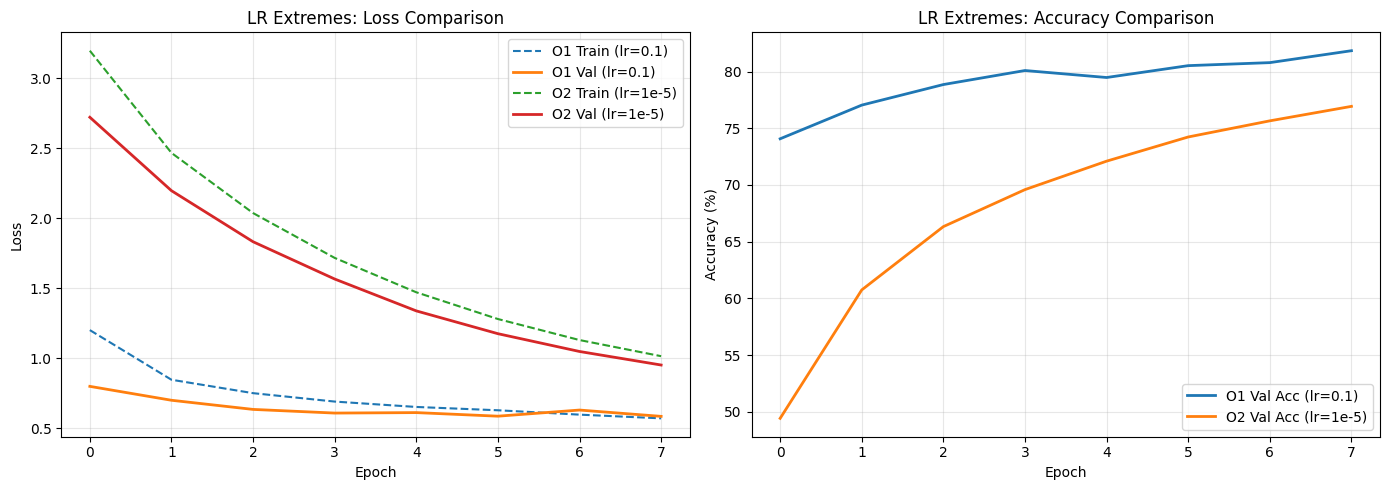

 curves_lr_extremes.png saved!


In [33]:
# График для O1 и O2 (экстремальные LR)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_o1['train_loss'], label='O1 Train (lr=0.1)', linestyle='--')
axes[0].plot(history_o1['val_loss'], label='O1 Val (lr=0.1)', linewidth=2)
axes[0].plot(history_o2['train_loss'], label='O2 Train (lr=1e-5)', linestyle='--')
axes[0].plot(history_o2['val_loss'], label='O2 Val (lr=1e-5)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LR Extremes: Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_o1['val_acc'], label='O1 Val Acc (lr=0.1)', linewidth=2)
axes[1].plot(history_o2['val_acc'], label='O2 Val Acc (lr=1e-5)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('LR Extremes: Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" curves_lr_extremes.png saved!")

In [34]:
# Добавляем O1-O3 в results
results.append({
    'experiment_id': 'O1', 'dataset': 'EMNIST_balanced', 'seed': seed,
    'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
    'optimizer': 'Adam', 'lr': 1e-1, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': 8, 
    'best_val_accuracy': round(max(history_o1['val_acc']), 2), 
    'best_val_loss': round(min(history_o1['val_loss']), 4)
})

results.append({
    'experiment_id': 'O2', 'dataset': 'EMNIST_balanced', 'seed': seed,
    'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
    'optimizer': 'Adam', 'lr': 1e-5, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': 8, 
    'best_val_accuracy': round(max(history_o2['val_acc']), 2), 
    'best_val_loss': round(min(history_o2['val_loss']), 4)
})

results.append({
    'experiment_id': 'O3', 'dataset': 'EMNIST_balanced', 'seed': seed,
    'model_summary': '512-256-128/ReLU/dropout=0.0/BN=True',
    'optimizer': 'SGD', 'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-4,
    'epochs_trained': 15, 
    'best_val_accuracy': round(max(history_o3['val_acc']), 2), 
    'best_val_loss': round(min(history_o3['val_loss']), 4)
})

# Пересохраняем CSV
df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("\n Final runs.csv:")
print(df[['experiment_id', 'optimizer', 'lr', 'best_val_accuracy', 'epochs_trained']])
print(" runs.csv saved (all experiments)!")


 Final runs.csv:
  experiment_id optimizer       lr  best_val_accuracy  epochs_trained
0            E1      Adam  0.00100              85.07              10
1            E2      Adam  0.00100              84.39              10
2            E3      Adam  0.00100              86.16              10
3            E4      Adam  0.00100              85.98              18
4            O1      Adam  0.10000              81.84               8
5            O2      Adam  0.00001              76.93               8
6            O3       SGD  0.00100              84.87              15
 runs.csv saved (all experiments)!


In [35]:
# Финальный тест лучшей модели (E4) 
print("\n" + "="*50)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
print("="*50)

# Загружаем лучшую модель
model_best = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout=0.0,
    use_bn=True
).to(device)

model_best.load_state_dict(torch.load('artifacts/best_model.pt', map_location=device))
print(" Best model loaded from artifacts/best_model.pt")

# Оценка на test
test_loss, test_acc = evaluate(model_best, test_loader, criterion, device)
print(f"\n FINAL TEST RESULTS:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.2f}%")

# Добавляем в отчёт (можно сохранить в отдельную переменную)
final_test_accuracy = test_acc


ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET
 Best model loaded from artifacts/best_model.pt

 FINAL TEST RESULTS:
   Test Loss: 0.4860
   Test Accuracy: 85.45%
